In [1]:
import pandas as pd
import matplotlib
from matplotlib import pyplot as plt
import seaborn as sns
sns.set()
import numpy as np

In [2]:
df = pd.read_csv("Vessel_X.txt", header=None)
df.columns = [("f" + str(x)) for x in range(100, 401)]
Y = pd.read_csv("Vessel_Y.txt", header=None)
dfY = df.copy()
dfY['Y'] = Y.loc[:,0]

In [ ]:
a = df.stack().to_frame().reset_index()[['level_1', 0]]
a.columns = ["frecuencia", "valor"]

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=1, dpi=200, figsize=(32, 8))

sns.set_theme(style="ticks", palette="flare")

sns.boxplot(x="frecuencia", y="valor", data=a, ax=ax, showfliers=False)
#sns.despine(offset=10, trim=True)

ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.show()

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=1, dpi=200, figsize=(32, 8))

sns.set_theme(style="ticks", palette="pastel")

sns.lineplot(x="frecuencia", y="valor", data=a, ax=ax)
#sns.despine(offset=10, trim=True)
#ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

plt.show()

In [ ]:
df

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button
sns.set_theme(style="ticks", palette="flare")


df = pd.read_csv("Vessel_X.txt", header=None)
df.columns = [("f" + str(x)) for x in range(100, 401)]


fig, ax = plt.subplots()
plt.subplots_adjust(bottom=0.25)

def strfreq(f):
    return 'f'+str(int(f))

def update(val):
    ax.clear()
#    ax.set_xlim()
    freq = [strfreq(x) for x in range(int(val)-1, int(val)+2)]
    for f in freq:
        sns.kdeplot(np.array(df[f]), ax=ax, log_scale=True)

axfreq = plt.axes([0.25, 0.1, 0.65, 0.03])

freq_slider = Slider(
    ax=axfreq,
    label='Frequency [Hz]',
    valmin=101,
    valmax=399,
    valinit=200,
    valfmt='%0.0f',
)
freq_slider.on_changed(update)

plt.show()

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button
sns.set_theme(style="ticks", palette="flare")

df = pd.read_csv("Vessel_X.txt", header=None)
df.columns = [("f" + str(x)) for x in range(100, 401)]

fig, ax = plt.subplots()
plt.subplots_adjust(bottom=0.25)

def update(val):
    ax.clear()
    ax.set_xlim(100, 400)
    ax.set_ylim(0, 8500)
    sns.scatterplot(x=range(100, 401), y=df.mean(), ax=ax)
    sns.scatterplot(x=range(100, 401), y=df.loc[int(val)], ax=ax)

axvasj = plt.axes([0.25, 0.1, 0.65, 0.03])

freq_slider = Slider(
    ax=axvasj,
    label='Número de Vasija',
    valmin=0,
    valmax=179,
    valinit=0,
    valfmt='%0.0f',
)
freq_slider.on_changed(update)

plt.show()

[]

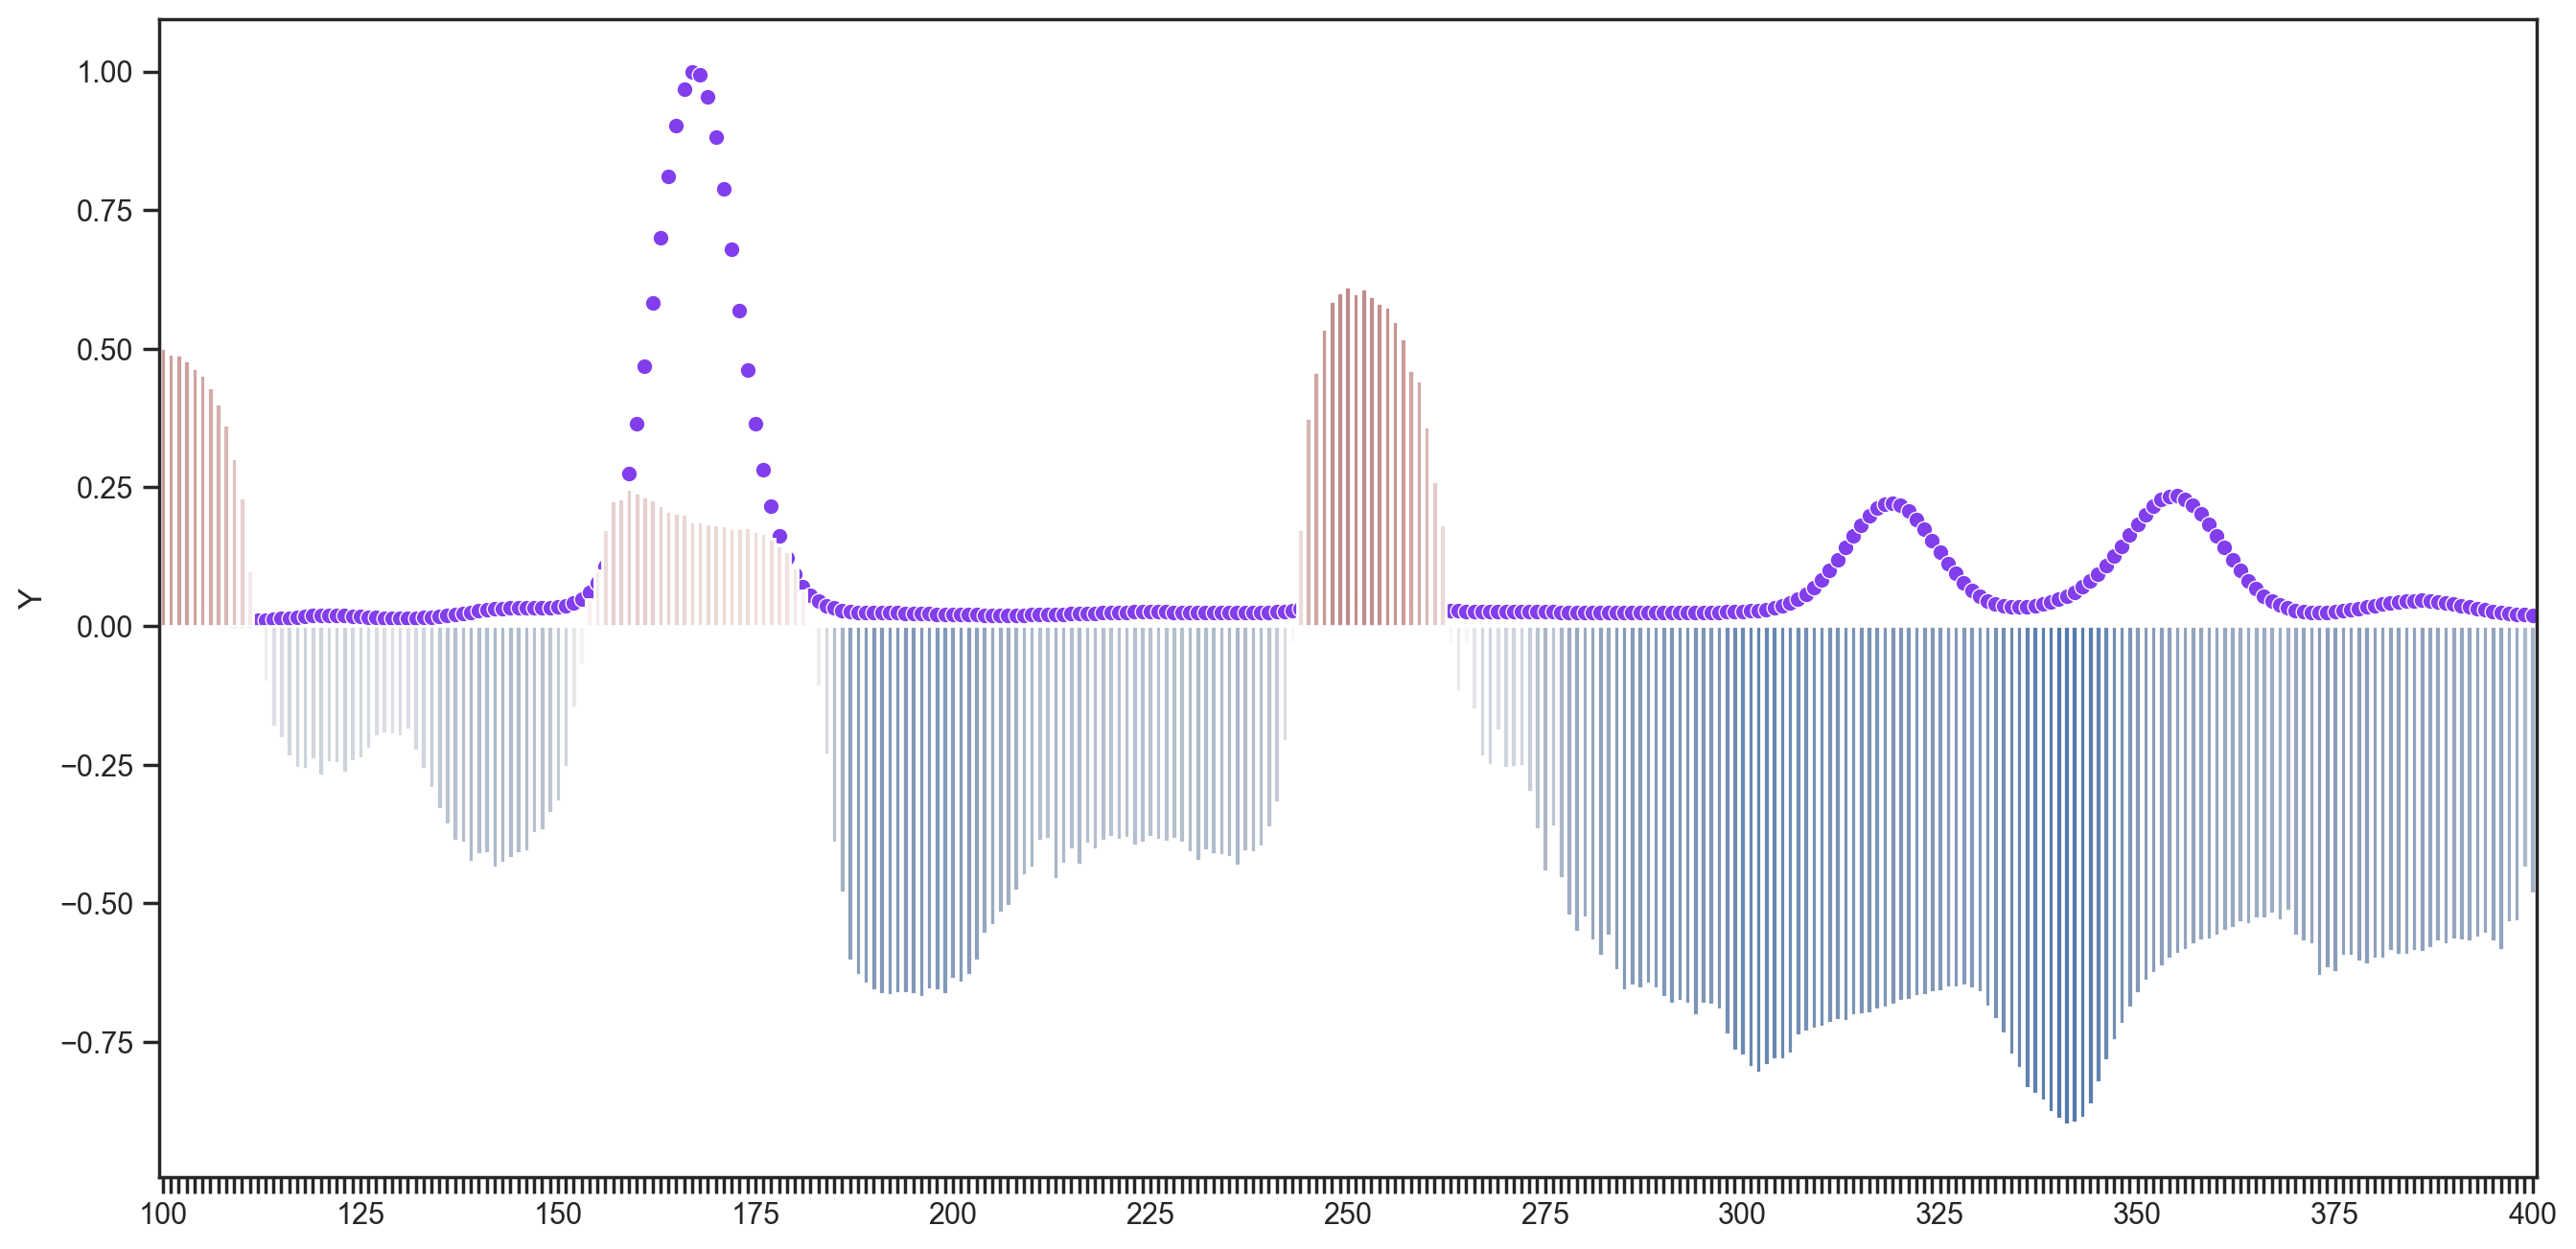

In [207]:
corrs = dfY.corr()['Y'].drop('Y')

colores = sns.color_palette("vlag", as_cmap=True).colors
coloresplot = [colores[int(128 + y*128)] for y in pd.Series(corrs)]


fig, ax = plt.subplots(nrows=1, ncols=1, dpi=200, figsize=(16, 8))
sns.set_theme(style="ticks", palette="flare")

X = df.mean()
X = X/X.max()

ax.set_xlim(100, 400)

sns.barplot(x=list(range(100, 401)), y=pd.Series(corrs), palette=coloresplot, ax=ax)
sns.scatterplot(x=list(range(0, 301)), y=X, ax=ax, color='#823EED')

ax.set_xticklabels([t if not i%25 else "" for i,t in enumerate(ax.get_xticklabels())])
plt.plot()

[]

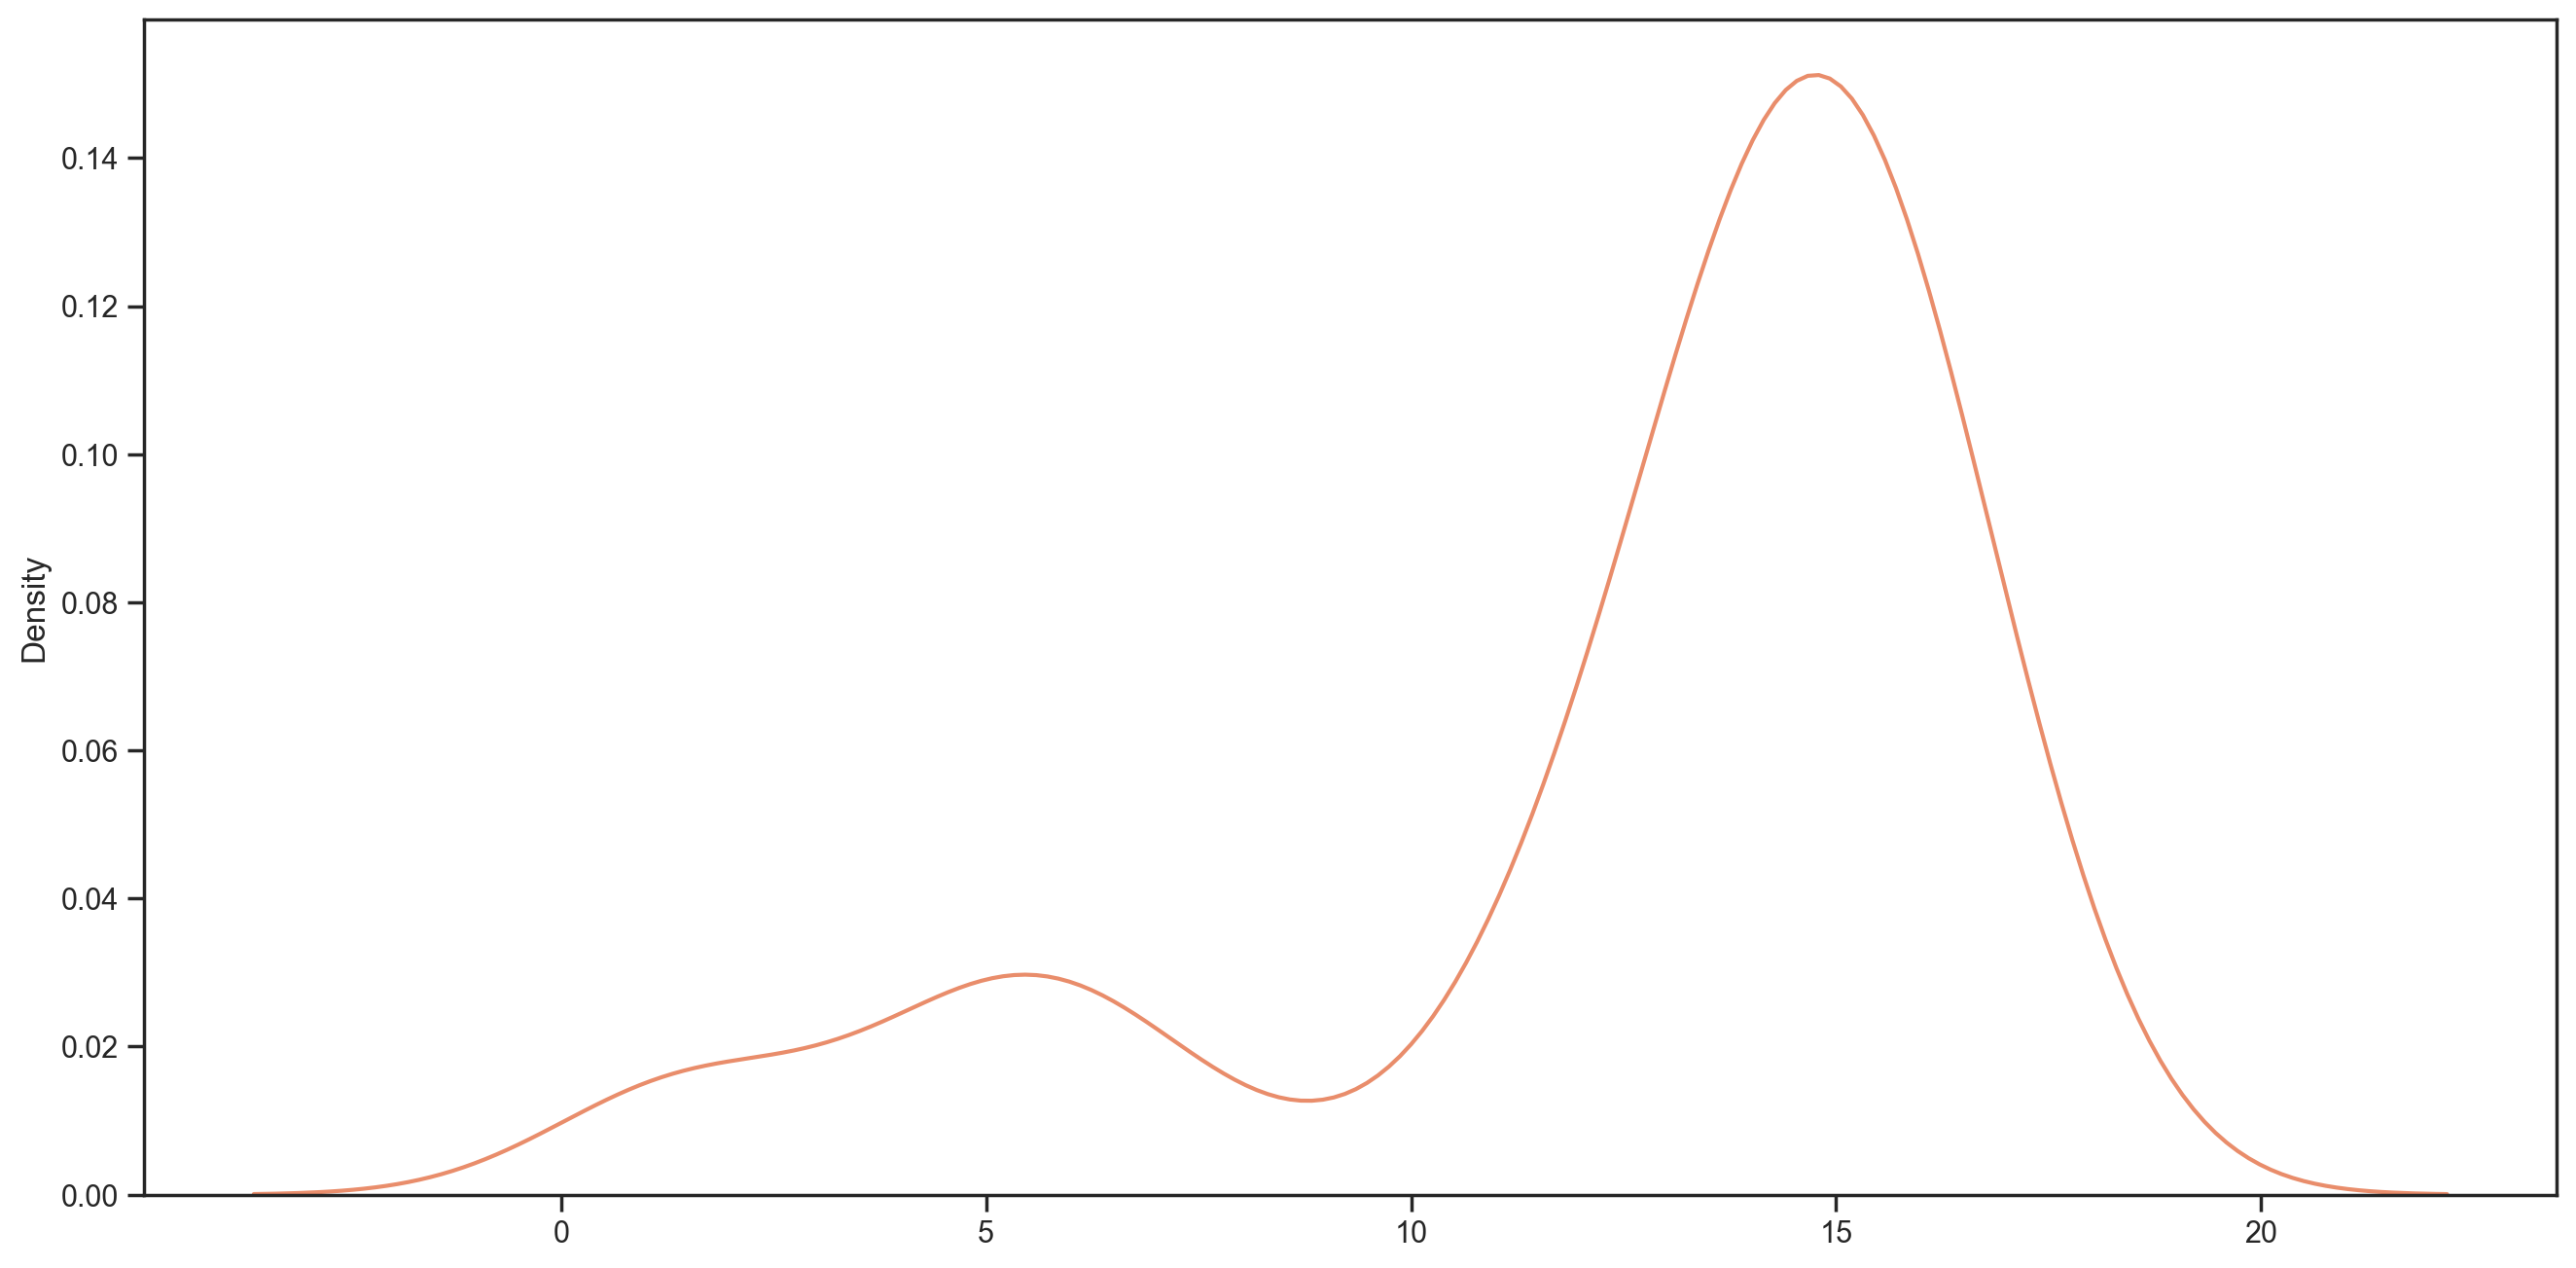

In [208]:
fig, ax = plt.subplots(nrows=1, ncols=1, dpi=200, figsize=(16, 8))

sns.kdeplot(np.array(dfY['Y']), ax=ax)

plt.plot()

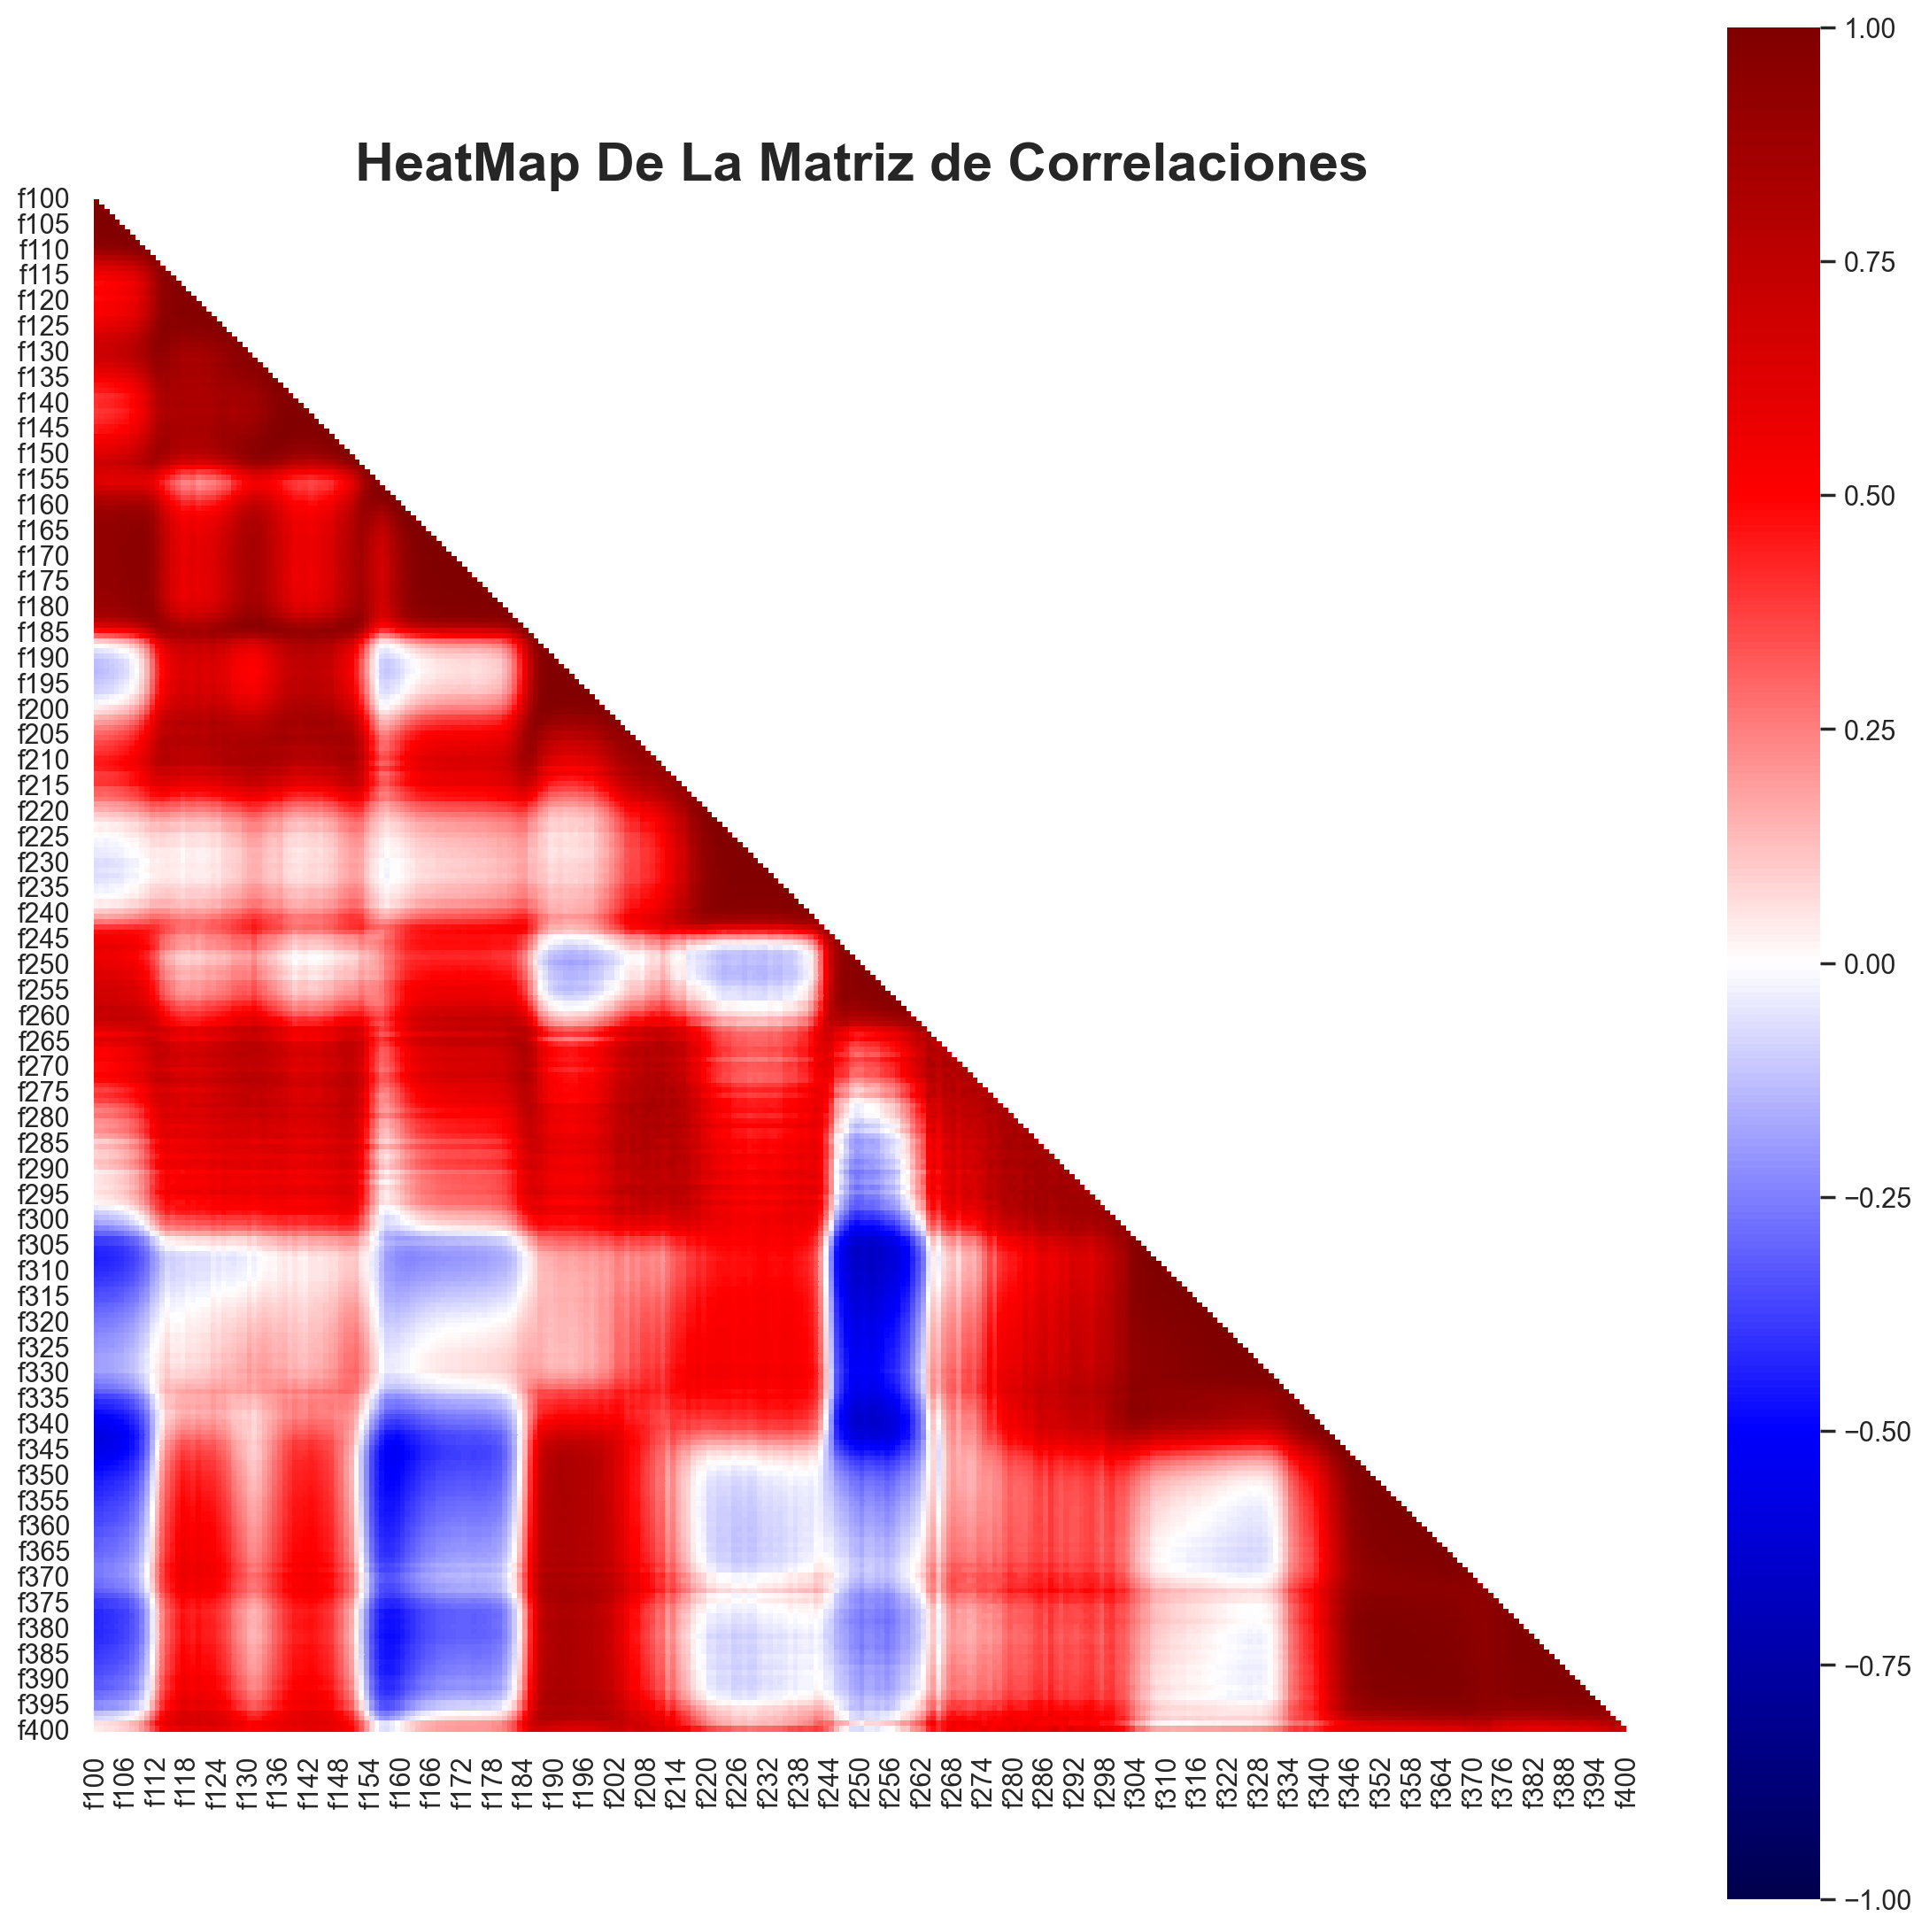

In [223]:

corrs = df.corr()

mask = np.zeros_like(corrs)
mask[np.triu_indices_from(mask)] = True    
with sns.axes_style("white"):
      f, ax = plt.subplots(dpi=200, figsize=(14, 14))
      ax = sns.heatmap(corrs, mask=mask, vmin=-1, vmax=1, square=True, cmap='seismic')
      ax.set_title("HeatMap De La Matriz de Correlaciones", weight='bold', size=22)
